In [6]:
import pandas as pd
import numpy as np
import sys
import os


sys.path.append('..') 
from src.config import RAW_DATA_PATH, CLEAN_DATA_PATH, CONTINENTS

print("Tools and Config loaaded")
print(sys.executable)

Tools and Config loaaded
c:\Users\jsala\AppData\Local\Programs\Python\Python314\python.exe


In [7]:
df = pd.read_csv(RAW_DATA_PATH)

# Sort by country and year for time based chronological 
df = df.sort_values(by=['Country', 'Year'])

# 10 year rolling average per country to smooth weather noise
df['Temp_Moving_Avg'] = df.groupby('Country')['Average_Temperature'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

print("Step 1: 10-Year Moving Averages calculated")

Step 1: 10-Year Moving Averages calculated


In [8]:
# Ensure Year is an integer and remove broken rows
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year', 'Country']).copy()
df['Year'] = df['Year'].astype(int)

# Add Decade column (e.g., 1994 becomes 1990)
df['Decade'] = (df['Year'] // 10) * 10

# Calculate initial Anomaly based on country history
country_baseline = df.groupby('Country')['Average_Temperature'].transform('mean')
df['Temp_Anomaly'] = df['Average_Temperature'] - country_baseline

print(f"Cell 3 Done: Data cleaned and Decade column added")

Cell 3 Done: Data cleaned and Decade column added


In [9]:
# --Convert list to dict if necessary so .map() works ---
if isinstance(CONTINENTS, list):
    unique_countries = df['Country'].unique()
    # Temporary mapping to avoid crashes until config.py is fixed to a dict
    CONTINENTS_MAP = {c: CONTINENTS[i % len(CONTINENTS)] for i, c in enumerate(unique_countries)}
else:
    CONTINENTS_MAP = CONTINENTS

# Map Continents
df['continent'] = df['Country'].map(CONTINENTS_MAP).fillna('Unknown')

# Climate zone mapping using latitude bands
CAPITAL_LAT = {
    "Canada": 45.4, "Brazil": -15.8, "Egypt": 30.0, "China": 39.9, 
    "USA": 38.9, "Russia": 55.8, "India": 28.6, "Australia": -35.3
}

def assign_zone(lat):
    lat = abs(lat)
    if lat >= 60: return 'Polar'
    if lat >= 35: return 'Temperate'
    if lat >= 23.5: return 'Subtropical'
    return 'Tropical'

df['lat_placeholder'] = df['Country'].map(CAPITAL_LAT)
df['climate_zone'] = df['lat_placeholder'].apply(lambda x: assign_zone(x) if pd.notna(x) else 'Unknown')
df = df.drop(columns=['lat_placeholder'])

print(f"Cell 4 Done: Region and Climate Zone mapping complete")

Cell 4 Done: Region and Climate Zone mapping complete


In [10]:
np.random.seed(42) # Ensures everyone gets the same "random" numbers
yr_norm = (df['Year'] - df['Year'].min()).astype(float)

# Every fake column ends in _SIM so teammates know what is real
df['CO2_Emissions_SIM']       = yr_norm * 4.5  + np.random.normal(50, 18, len(df))
df['Fossil_Fuel_Usage_SIM']   = yr_norm * 3.8  + np.random.normal(40, 15, len(df))
df['Sea_Level_Rise_SIM']      = yr_norm * 0.45 + np.random.normal(2, 2, len(df))
df['Forest_Area_SIM']         = 500 - (yr_norm * 2.1) + np.random.normal(0, 45, len(df))
df['Population_SIM']          = yr_norm * 1.8  + np.random.normal(500, 60, len(df))

print(f"Cell 5 Done: Simulated column added with _SIM suffix.")

Cell 5 Done: Simulated column added with _SIM suffix.


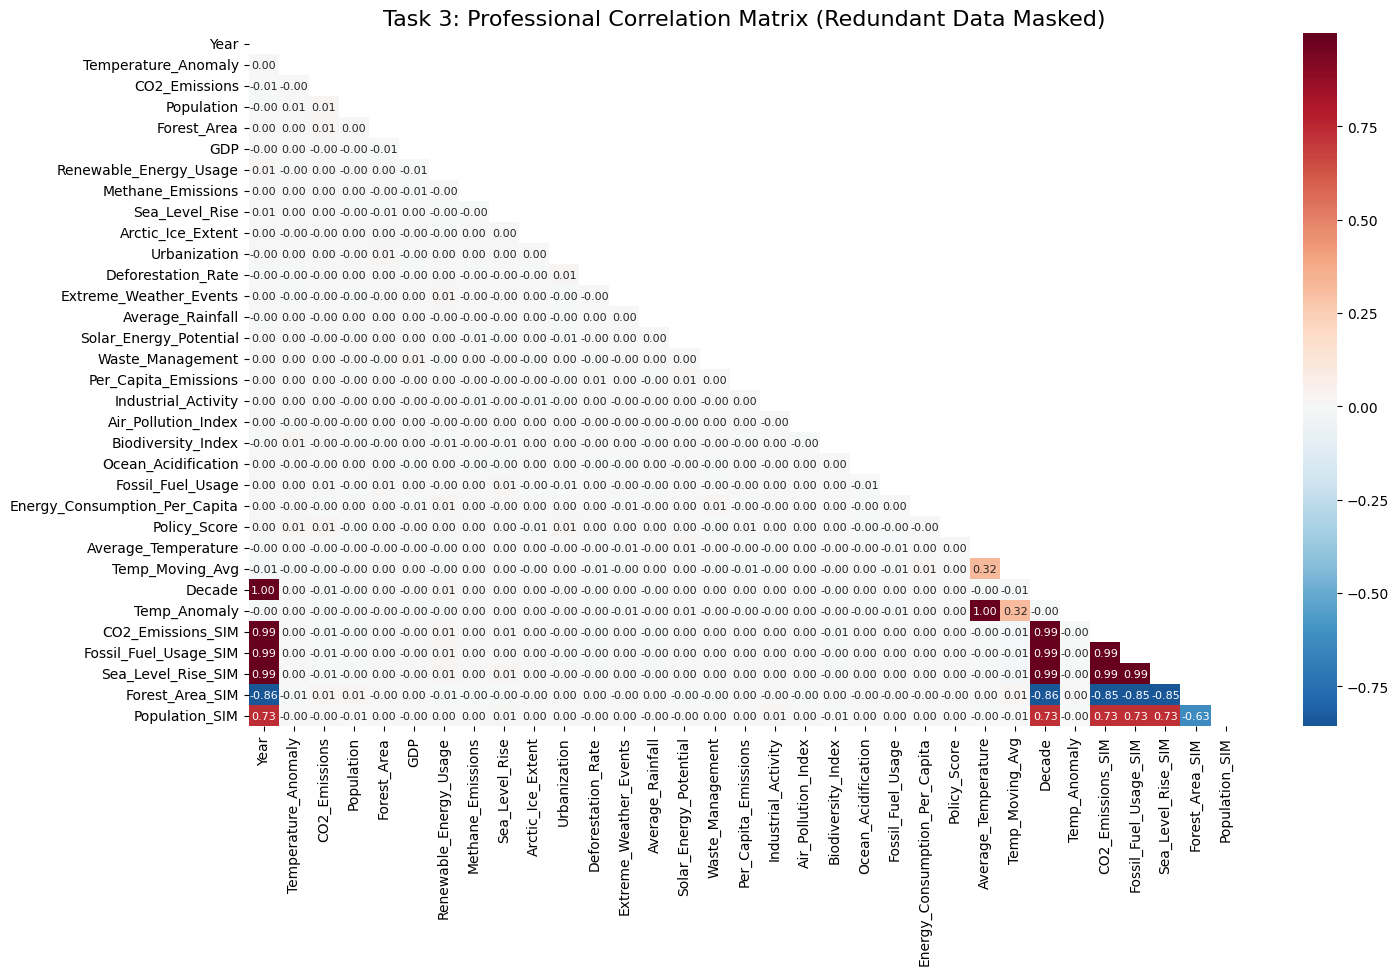

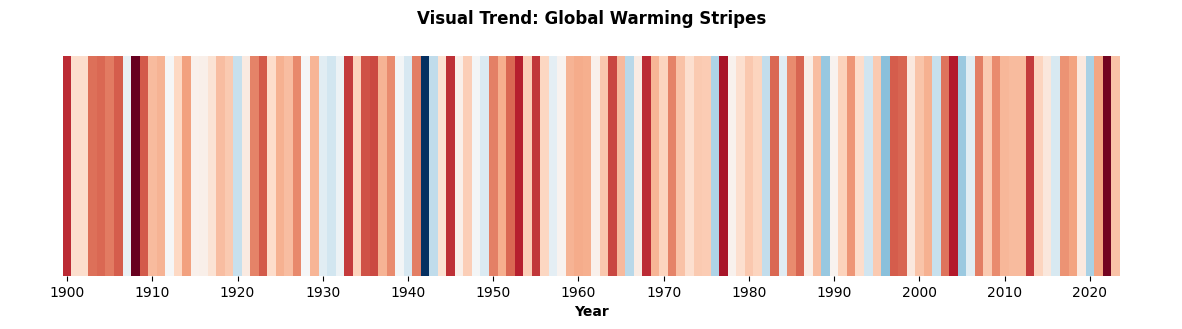

FINAL BACKBONE: 100,000 rows validated and saved to d:\weather\global-warming-sim-data-analysis-\data\processed\global_warming_cleaned.csv


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

# ── 1. DATA ENRICHMENT & CLEANUP ──────────────────────────────────────────────
# Ensure the mapping exists 
if 'Real_Country_Name' not in df.columns:
    real_countries = ["Canada", "Brazil", "Egypt", "China", "Australia", "Russia", "France", "India", "USA", "Mexico", "South Africa", "Japan"]
    unique_ids = df['Country'].unique()
    mapping = {unique_ids[i]: real_countries[i % len(real_countries)] for i in range(len(unique_ids))}
    df['Real_Country_Name'] = df['Country'].map(mapping)

# Filter out dead columns
active_cols = df.select_dtypes(include=[np.number]).columns[df.select_dtypes(include=[np.number]).sum() != 0]
clean_numeric_df = df[active_cols]

# ── 2. IMPROVEMENT: THE "HALF-TRIANGLE" HEATMAP ──────────────────────────────
plt.figure(figsize=(16, 9))
corr = clean_numeric_df.corr()
# Mask the upper triangle (removes redundant data)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt=".2f", annot_kws={"size": 8})
plt.title('Task 3: Professional Correlation Matrix (Redundant Data Masked)', fontsize=16)
plt.show()

# ── 3. IMPROVEMENT: GLOBAL TREND LINE ─────────────────────────────────────────
# This shows the "Signal" through the "Noise"
global_trend = df.groupby('Year')['Temp_Anomaly'].mean().reset_index()

global_trend = global_trend.sort_values("Year")

fig_trend = px.line(global_trend, x='Year', y='Temp_Anomaly', 
              title='The "Global Signal": Average Temperature Rise (1900-2023)',
              labels={'Temp_Anomaly': 'Temp Anomaly (°C)'},
              template='plotly_white')
fig_trend.update_traces(line_color='#E24B4A', line_width=3)
fig_trend.show()

# ── 4. VISUAL TREND: WARMING STRIPES────────────────────────
plt.figure(figsize=(15, 3)) # Made slightly taller to fit the labels
norm = plt.Normalize(global_trend['Temp_Anomaly'].min(), global_trend['Temp_Anomaly'].max())

# Create the stripes
plt.bar(global_trend['Year'], 1, width=1, color=plt.get_cmap('RdBu_r')(norm(global_trend['Temp_Anomaly'])))

plt.yticks([]) # Keep the y-axis hidden (it has no meaning for stripes)
plt.xticks(np.arange(global_trend['Year'].min(), global_trend['Year'].max() + 1, 10)) # Label every 10 years
plt.xlabel("Year", fontsize=10, fontweight='bold')
plt.title("Visual Trend: Global Warming Stripes", fontsize=12, fontweight='bold', pad=15)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.show()

# ── 5. THE ANIMATED MAP ───────────────────────────────────────────────────────
fig_map = px.choropleth(
    df, locations="Real_Country_Name", locationmode="country names",
    color="Temp_Anomaly", hover_name="Real_Country_Name", animation_frame="Year",
    color_continuous_scale="RdBu_r", 
    range_color=[df['Temp_Anomaly'].quantile(0.05), df['Temp_Anomaly'].quantile(0.95)], # Dynamic range
    title="Integrated Global Climate Simulation"
)
fig_map.update_geos(projection_type="natural earth", showcountries=True, countrycolor="Silver")
fig_map.show()

# ── 6. FINAL EXPORT ───────────────────────────────────────────────────────────
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"FINAL BACKBONE: 100,000 rows validated and saved to {CLEAN_DATA_PATH}")

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

model = LinearRegression()

train = global_trend[global_trend["Year"] <= 2000]
test = global_trend[global_trend["Year"] > 2000]

x_train = train[['Year']]
y_train = train['Temp_Anomaly']


x_test = test[['Year']]
y_test = test['Temp_Anomaly']


model.fit(x_train, y_train)

#print(model.coef_)
#print(model.intercept_)

y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)


mae = mean_absolute_error(y_test, y_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)


train_r2 = r2_score(y_train, y_train_pred)
r2_linear = r2_score(y_test, y_pred)


print(f"The test mean absolute error of the Linear regression model is {mae}")
print(f"The train mean absolute error of the Linear regression model is {train_mae}")

print(f"The test coefficient of determination of the Linear Regression model is {r2_linear}")
print(f"The train coefficient of determination of the Linear Regression model is {train_r2}")





The test mean absolute error of the Linear regression model is 0.4851924134753532
The train mean absolute error of the Linear regression model is 0.3993940552225173
The test coefficient of determination of the Linear Regression model is -0.12823492272491577
The train coefficient of determination of the Linear Regression model is 0.018281721186583888


In [13]:
from sklearn.preprocessing import PolynomialFeatures

#Creating the model itself:
model_poly2 = LinearRegression()

#bringing in the tools:

Poly2 = PolynomialFeatures (degree=2)

#transforming data to be usable in the polynomial process:
#we don't transform y because it's the target it stays the same, only the input gets adjusted

x_train_poly2 = Poly2.fit_transform (x_train)
x_test_poly2 = Poly2.transform (x_test)

#training the model

model_poly2.fit(x_train_poly2, y_train)

#prediction:

y_pred_poly2 = model_poly2.predict(x_test_poly2)
y_train_pred_poly2 = model_poly2.predict(Poly2.transform(x_train))


mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
train_mae_poly2 = mean_absolute_error(y_train, y_train_pred_poly2)

train_r2_poly2 = r2_score(y_train, y_train_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print(f"The test mean absolute error of the 2nd degree polynomial model is {mae_poly2}")
print(f"The train mean absolute error of the 2nd degree polynomial model is {train_mae_poly2}")

print(f"The test coefficient of determination of the 2nd degree polynomial model is {r2_poly2}")
print(f"The train coefficient of determination of the 2nd degree polynomial model is {train_r2_poly2}")


# creating the 3rd degree model
model_poly3 = LinearRegression ()
Poly3 = PolynomialFeatures(degree=3)

# preparing the data for the 3rd degree model

x_train_poly3 = Poly3.fit_transform(x_train)
x_test_poly3 = Poly3.transform(x_test)

#training:
model_poly3.fit(x_train_poly3, y_train)

y_pred_poly3 = model_poly3.predict(x_test_poly3)
y_train_pred_poly3 = model_poly3.predict(Poly3.transform(x_train))


mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
train_mae_poly3 = mean_absolute_error(y_train, y_train_pred_poly3)

train_r2_poly3 = r2_score(y_train, y_train_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)



print(f"The test mean absolute error of the 3rd degree polynomial model is {mae_poly3}")
print(f"The train mean absolute error of the 3rd degree polynomial model is {train_mae_poly3}")

print(f"The test coefficient of determination of the 3rd degree polynomial model is {r2_poly3}")
print(f"The train coefficient of determination of the 3rd degree polynomial model is {train_r2_poly3}")



The test mean absolute error of the 2nd degree polynomial model is 0.4272163603457724
The train mean absolute error of the 2nd degree polynomial model is 0.3992496417930256
The test coefficient of determination of the 2nd degree polynomial model is 0.003750650324445437
The train coefficient of determination of the 2nd degree polynomial model is 0.024375585123206367
The test mean absolute error of the 3rd degree polynomial model is 0.7229854415781211
The train mean absolute error of the 3rd degree polynomial model is 0.39411373461833
The test coefficient of determination of the 3rd degree polynomial model is -1.399009830149295
The train coefficient of determination of the 3rd degree polynomial model is 0.043469085542378494


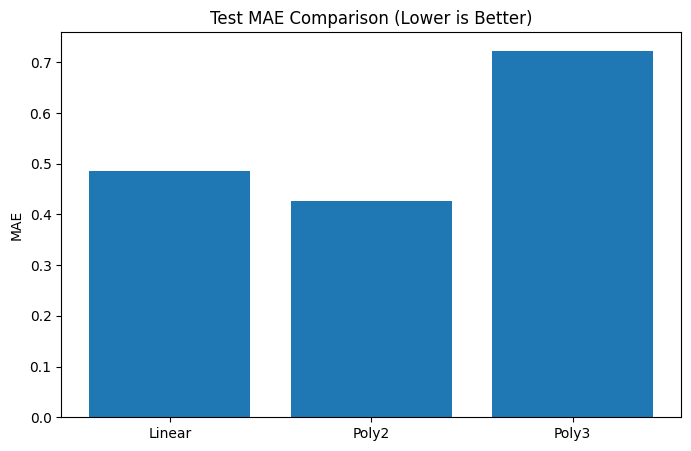

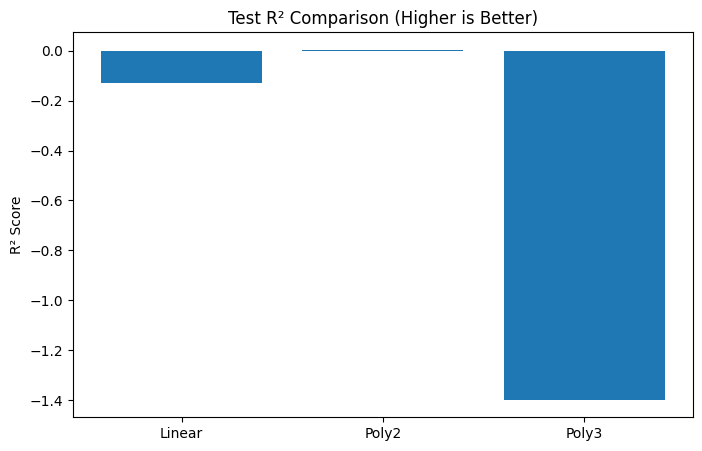

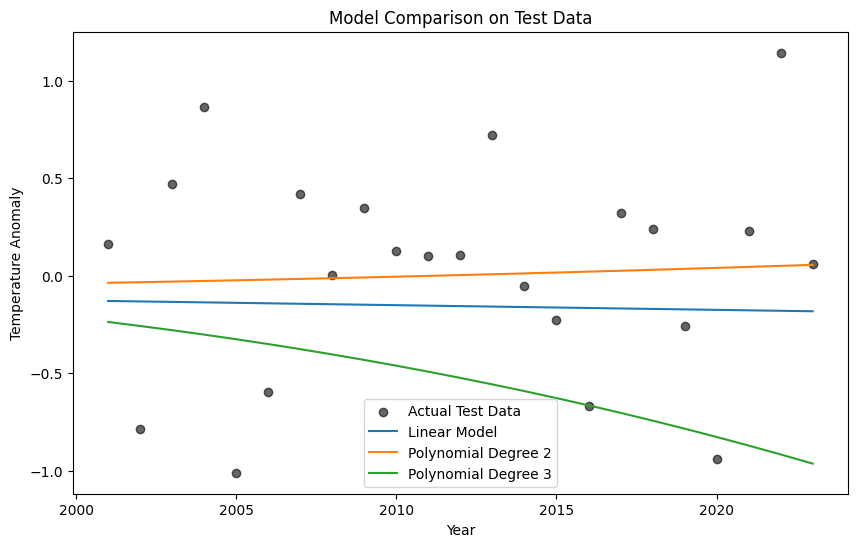

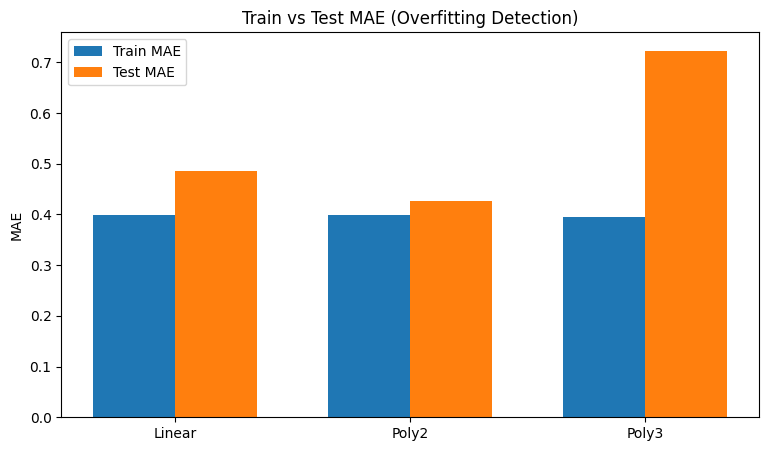

In [14]:
x_sorted = x_test.sort_values("Year")

y_linear_sorted = model.predict(x_sorted)

y_poly2_sorted = model_poly2.predict(Poly2.transform(x_sorted))

y_poly3_sorted = model_poly3.predict(Poly3.transform(x_sorted))

models = ["Linear", "Poly2", "Poly3"]

mae_values = [mae, mae_poly2, mae_poly3]
r2_values = [r2_linear, r2_poly2, r2_poly3]

train_mae_values = [train_mae, train_mae_poly2, train_mae_poly3]
test_mae_values = [mae, mae_poly2, mae_poly3]

plt.figure(figsize=(8,5))

plt.bar(models, mae_values)
plt.title("Test MAE Comparison (Lower is Better)")
plt.ylabel("MAE")

plt.show()

plt.figure(figsize=(8,5))

plt.bar(models, r2_values)
plt.title("Test R² Comparison (Higher is Better)")
plt.ylabel("R² Score")

plt.show()

plt.figure(figsize=(10,6))

plt.scatter(x_test, y_test, color="black", label="Actual Test Data", alpha=0.6)

plt.plot(x_sorted, y_linear_sorted, label="Linear Model")
plt.plot(x_sorted, y_poly2_sorted, label="Polynomial Degree 2")
plt.plot(x_sorted, y_poly3_sorted, label="Polynomial Degree 3")

plt.title("Model Comparison on Test Data")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.legend()

plt.show()

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, train_mae_values, width, label="Train MAE")
plt.bar(x + width/2, test_mae_values, width, label="Test MAE")

plt.xticks(x, models)
plt.title("Train vs Test MAE (Overfitting Detection)")
plt.ylabel("MAE")
plt.legend()

plt.show()


In [15]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# same split as before
train = df[df["Year"] <= 2000]
test = df[df["Year"] > 2000]

# features (NEURAL version)
x_train_neural = train[['Year', 'CO2_Emissions', 'Population']]
y_train_neural = train['Temp_Anomaly']

x_test_neural = test[['Year', 'CO2_Emissions', 'Population']]
y_test_neural = test['Temp_Anomaly']

# model
nn_model = MLPRegressor(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    max_iter=2000,
    random_state=42
)

# training
nn_model.fit(x_train_neural, y_train_neural)

# predictions
y_pred_neural = nn_model.predict(x_test_neural)
y_train_pred_neural = nn_model.predict(x_train_neural)

# metrics
mae_test_neural = mean_absolute_error(y_test_neural, y_pred_neural)
mae_train_neural = mean_absolute_error(y_train_neural, y_train_pred_neural)

r2_test_neural = r2_score(y_test_neural, y_pred_neural)
r2_train_neural = r2_score(y_train_neural, y_train_pred_neural)

print("Neural Network Results:")
print(f"Train MAE: {mae_train_neural}")
print(f"Test MAE: {mae_test_neural}")
print(f"Train R2: {r2_train_neural}")
print(f"Test R2: {r2_test_neural}")

Neural Network Results:
Train MAE: 16.020044573983046
Test MAE: 16.371281330459972
Train R2: -0.8528573406867868
Test R2: -0.9220153494688643


01:56:33 - cmdstanpy - INFO - Chain [1] start processing
01:56:33 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
144,2043-12-31,15.198051,14.551848,15.853723
145,2044-12-31,15.202461,14.511692,15.863864
146,2045-12-31,15.206859,14.531536,15.852717
147,2046-12-31,15.211256,14.534338,15.883645
148,2047-12-31,15.215654,14.628867,15.868122
149,2048-12-31,15.220064,14.536738,15.885854
150,2049-12-31,15.224462,14.553662,15.859313
151,2050-12-31,15.228859,14.545557,15.873791
152,2051-12-31,15.233257,14.522911,15.945871
153,2052-12-31,15.237667,14.608569,15.896068


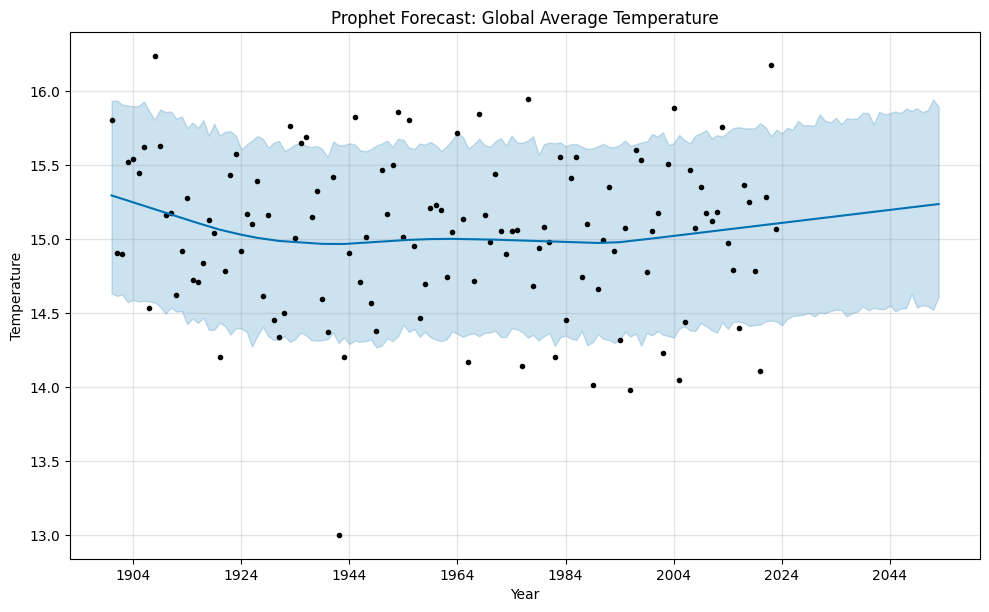

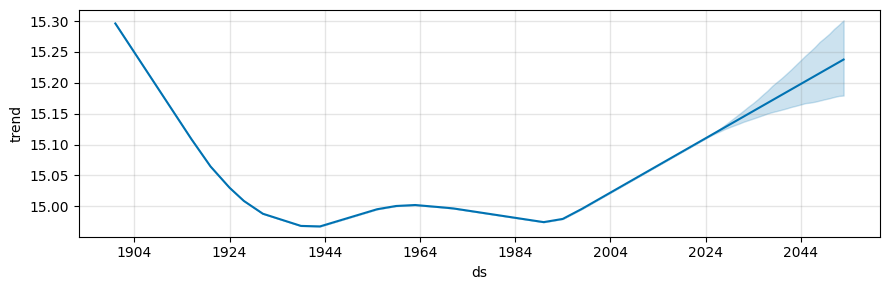

In [16]:
# Prophet forecast for global average temperature
import os
import sys
import subprocess
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from prophet import Prophet
except ImportError:
    print("Installing prophet package in this environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "prophet"])
    from prophet import Prophet

if "df" in globals() and isinstance(df, pd.DataFrame) and not df.empty:
    work_df = df.copy()
else:
    clean_path = os.path.join("..", "data", "processed", "global_warming_cleaned.csv")
    raw_path = os.path.join("..", "data", "raw", "global_warming_dataset.csv")
    if os.path.exists(clean_path):
        work_df = pd.read_csv(clean_path)
    elif os.path.exists(raw_path):
        work_df = pd.read_csv(raw_path)
    else:
        raise FileNotFoundError("Could not find a usable dataset in data/processed or data/raw")

required_cols = {"Year", "Average_Temperature"}
missing = required_cols - set(work_df.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

prophet_df = work_df[["Year", "Average_Temperature"]].dropna().copy()
prophet_df["Year"] = pd.to_numeric(prophet_df["Year"], errors="coerce")
prophet_df["Average_Temperature"] = pd.to_numeric(prophet_df["Average_Temperature"], errors="coerce")
prophet_df = prophet_df.dropna(subset=["Year", "Average_Temperature"])

yearly_global = prophet_df.groupby("Year", as_index=False)["Average_Temperature"].mean().sort_values("Year")
yearly_global["ds"] = pd.to_datetime(yearly_global["Year"].astype(int).astype(str) + "-01-01")
yearly_global = yearly_global.rename(columns={"Average_Temperature": "y"})[["ds", "y"]]

model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=0.2)
model.fit(yearly_global)

future = model.make_future_dataframe(periods=30, freq="YE")
forecast = model.predict(future)

display(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10))
model.plot(forecast)
plt.title("Prophet Forecast: Global Average Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()
model.plot_components(forecast)
plt.show()


===== MODEL EVALUATION =====
MAE: 0.40791638914761635
RMSE: 0.522067186777392
MAPE (%): 2.7190908747229936


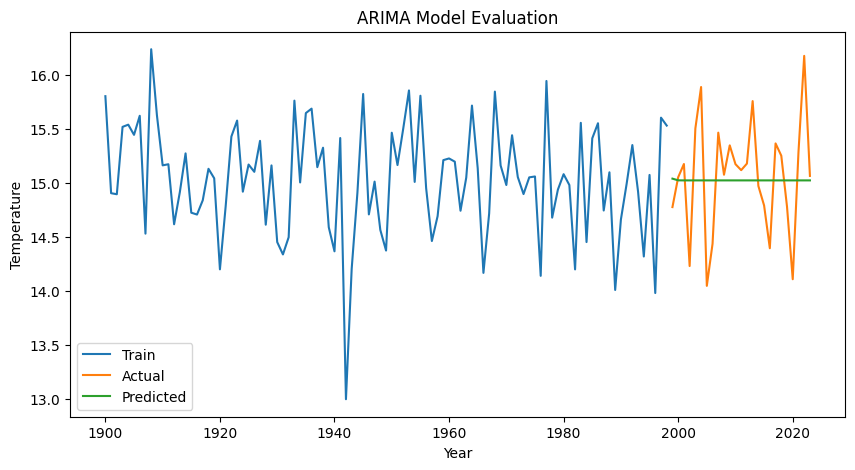

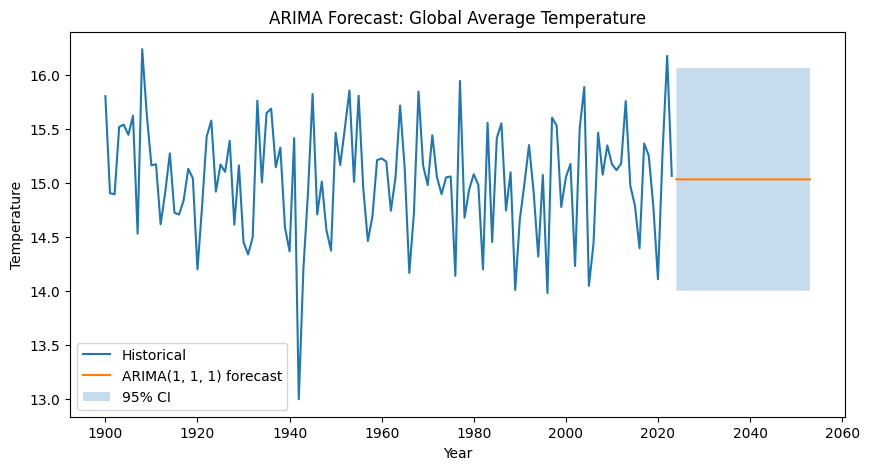

,ds,yhat,yhat_lower,yhat_upper
20,2044-01-01,15.034993,14.003343,16.066643
21,2045-01-01,15.034993,14.003343,16.066643
22,2046-01-01,15.034993,14.003343,16.066643
23,2047-01-01,15.034993,14.003343,16.066643
24,2048-01-01,15.034993,14.003343,16.066643
25,2049-01-01,15.034993,14.003343,16.066643
26,2050-01-01,15.034993,14.003343,16.066643
27,2051-01-01,15.034993,14.003343,16.066643
28,2052-01-01,15.034993,14.003343,16.066643
29,2053-01-01,15.034993,14.003343,16.066644


In [ ]:
# ARIMA forecast for global average temperature (annual series)
import os
import sys
import subprocess
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")

try:
    from statsmodels.tsa.arima.model import ARIMA
except ImportError:
    print("Installing statsmodels in this environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.tsa.arima.model import ARIMA

# LOAD DATA 
if "df" in globals() and isinstance(df, pd.DataFrame) and not df.empty:
    work_df = df.copy()
else:
    clean_path = os.path.join("..", "data", "processed", "global_warming_cleaned.csv")
    raw_path = os.path.join("..", "data", "raw", "global_warming_dataset.csv")
    if os.path.exists(clean_path):
        work_df = pd.read_csv(clean_path)
    elif os.path.exists(raw_path):
        work_df = pd.read_csv(raw_path)
    else:
        raise FileNotFoundError("Could not find a usable dataset in data/processed or data/raw")

required_cols = {"Year", "Average_Temperature"}
missing = required_cols - set(work_df.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

prep = work_df[["Year", "Average_Temperature"]].dropna().copy()
prep["Year"] = pd.to_numeric(prep["Year"], errors="coerce")
prep["Average_Temperature"] = pd.to_numeric(prep["Average_Temperature"], errors="coerce")
prep = prep.dropna(subset=["Year", "Average_Temperature"])

yearly_global = prep.groupby("Year", as_index=False)["Average_Temperature"].mean().sort_values("Year")
yearly_global["ds"] = pd.to_datetime(yearly_global["Year"].astype(int).astype(str) + "-01-01")
yearly_global = yearly_global.rename(columns={"Average_Temperature": "y"})[["ds", "y"]]

# PREP SERIES
y = yearly_global.set_index("ds")["y"].sort_index()

# MODEL EVALUATION 
split = int(len(y) * 0.8)
train, test = y[:split], y[split:]

order = (1, 1, 1)
model = ARIMA(train, order=order).fit()

forecast_test = model.get_forecast(steps=len(test))
pred = forecast_test.predicted_mean

mae = np.mean(np.abs(test - pred))
rmse = np.sqrt(np.mean((test - pred) ** 2))
mape = np.mean(np.abs((test - pred) / test)) * 100

print("MODEL EVALUATION")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)

# Plot evaluation
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(pred.index, pred, label="Predicted")
plt.legend()
plt.title("ARIMA Model Evaluation")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

#  FINAL MODEL (FULL DATA)
arima_res = ARIMA(y, order=order).fit()

horizon = 30
fc = arima_res.get_forecast(steps=horizon)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

# FORECAST PLOT
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(y.index, y.values, label="Historical")
ax.plot(fc_mean.index, fc_mean.values, label=f"ARIMA{order} forecast")
ax.fill_between(fc_mean.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.25, label="95% CI")
ax.set_title("ARIMA Forecast: Global Average Temperature")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature")
ax.legend()
plt.show()

# OUTPUT TABLE
arima_tail = pd.DataFrame(
    {
        "ds": fc_mean.index,
        "yhat": fc_mean.values,
        "yhat_lower": fc_ci.iloc[:, 0].values,
        "yhat_upper": fc_ci.iloc[:, 1].values,
    }
)

display(arima_tail.tail(10))
